#Naive Bayes Implementation using Adult Income Dataset (Census Income)

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

In [2]:
filename = files.upload()  # returns dict
df = pd.read_csv(list(filename.keys())[0])
print("Columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Saving adult.csv to adult.csv
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']

First few rows:
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  

## Data Preprocessing

In [3]:
categorical_features = [
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
]
target_col = 'income'

# handle missing values
X_cat = df[categorical_features + [target_col]].copy() # copy to prevent modifying original df
for col in categorical_features:
    if col in X_cat.columns:
        X_cat[col] = X_cat[col].fillna('Missing').replace('?', 'Missing')

In [4]:
# encode categories into integers
label_encoders = {}
X_encoded = X_cat.copy()
for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_cat[col])  # 'Private'→1, 'Self-emp'→5, etc.
    label_encoders[col] = le

# encode '<=50K'→0, '>50K'→1
le_target = LabelEncoder()
y = le_target.fit_transform(X_encoded[target_col])

X_final = X_encoded[[col for col in categorical_features]]
print(f"\nDataset ready: {X_final.shape} features, {len(y)} samples")
print(f"Target classes: {le_target.classes_}")


Dataset ready: (32561, 8) features, 32561 samples
Target classes: ['<=50K' '>50K']


In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X_final, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

## Naive Bayes Implementation

In [6]:
class CustomNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.class_log_prior_ = None
        self.feature_log_prob_ = None
        self.classes_ = None
        self.n_features_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape
        self.n_features_ = n_features

        # class priors: P(C_k) = (count_k + α) / (N + α * num_classes) + take log for numeric stability
        # alpha for laplace smoothing to avoid zero probs
        self.class_log_prior_ = np.log([(np.sum(y == k) + self.alpha) / (n_samples + self.alpha * len(self.classes_)) for k in self.classes_])

        # Store global maxes for consistent array sizes
        global_maxes = X.max(axis=0).astype(int)

        # feature likelihoods: P(x_i|C_k) = (count + α) / (class_count + α * n_values)
        self.feature_log_prob_ = []
        for k in self.classes_:
            X_k = X[y == k] # get all samples belonging to class k
            n_class = len(X_k)

            # for each feature, count occurrences of each value
            feature_log_probs = [] # temp storage for class k's features (log probabilities)
            for j in range(n_features):
                values, counts = np.unique(X_k[:, j], return_counts=True) # unique values seen + frequency of each value for feature j
                n_values = len(values)

                # smooth probabilities for each feature
                probs = (counts + self.alpha) / (n_class + self.alpha * n_values)
                log_probs = np.log(probs) # to avoid underflow

                # full probability vector (size = max_value + 1)
                max_val = int(global_maxes[j])
                full_log_probs = np.full(max_val + 1, -np.inf)
                full_log_probs[values] = log_probs
                feature_log_probs.append(full_log_probs)

            self.feature_log_prob_.append(feature_log_probs)

        return self


    # compute log(P(class | feature)) for all classes
    def predict_log_proba(self, X):
        n_samples, n_features = X.shape
        class_log_proba = np.zeros((n_samples, len(self.classes_)))

        # compute log P(class | features) for each sample using stored log probs
        for i, x in enumerate(X):  # for each test sample (person)
            for k in range(len(self.classes_)):  # try each class (0: <=50K, 1: >50K)
                # log P(C_k) + Σ log P(x_i|C_k) for all features
                log_prob = self.class_log_prior_[k]  # start with class prior

                for j in range(n_features):  # for each feature
                    feature_val = int(x[j])  # get this person's feature value

                    # lookup precomputed log P(x_j | C_k) from training
                    log_prob += self.feature_log_prob_[k][j][feature_val]

                class_log_proba[i, k] = log_prob  # store final log probability

        return class_log_proba

    # picks column (class) with highest log prob per row
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)] # .classes_ converts back to labels

##Analysis and Evaluation

In [7]:
# convert to numpy arrays
X_train = X_train.values if hasattr(X_train, 'values') else X_train
X_val = X_val.values if hasattr(X_val, 'values') else X_val
X_test = X_test.values if hasattr(X_test, 'values') else X_test


Smoothing Analysis (Validation Accuracy):
α= 0.1: Custom=0.7930
α= 0.5: Custom=0.7930
α= 1.0: Custom=0.7924
α= 2.0: Custom=0.7916
α= 5.0: Custom=0.7922


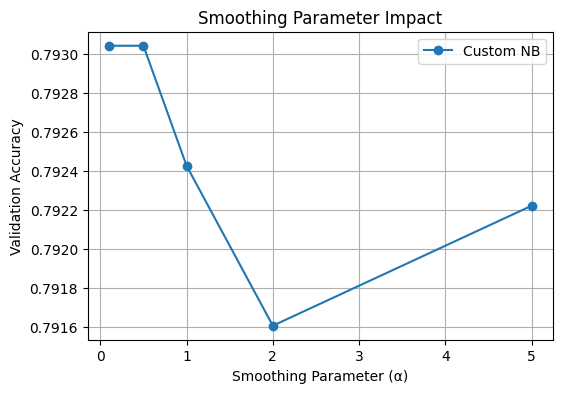

In [8]:
# smoothing parameter
alphas = [0.1, 0.5, 1.0, 2.0, 5.0]
custom_scores = []

for alpha in alphas:
    nb_custom = CustomNaiveBayes(alpha=alpha)
    nb_custom.fit(X_train, y_train)
    custom_pred = nb_custom.predict(X_val)
    custom_scores.append(accuracy_score(y_val, custom_pred))

print("\nSmoothing Analysis (Validation Accuracy):")
for alpha, c_score in zip(alphas, custom_scores):
    print(f"α={alpha:4.1f}: Custom={c_score:.4f}")

# Plot
plt.figure(figsize=(6, 4))
plt.plot(alphas, custom_scores, 'o-', label='Custom NB')
plt.xlabel('Smoothing Parameter (α)')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Smoothing Parameter Impact')
plt.grid(True)
plt.show()


In [9]:
# feature selection: leave-one-out analysis
feature_names = categorical_features
feature_importance = []

for i in range(len(feature_names)):
    # train with all but one feature
    X_train_subset = np.delete(X_train, i, axis=1)
    X_val_subset = np.delete(X_val, i, axis=1)

    nb = CustomNaiveBayes(alpha=1.0)
    nb.fit(X_train_subset, y_train)
    pred = nb.predict(X_val_subset)
    score = accuracy_score(y_val, pred)
    feature_importance.append(1.0 - score)  # drop in accuracy = importance

print("\nFeature Importance (Drop in Accuracy):")
for name, imp in zip(feature_names, feature_importance):
    print(f"{name:15}: {imp:.4f}")




Feature Importance (Drop in Accuracy):
workclass      : 0.2068
education      : 0.2405
marital.status : 0.1873
occupation     : 0.2242
relationship   : 0.1814
race           : 0.2047
sex            : 0.2006
native.country : 0.2039


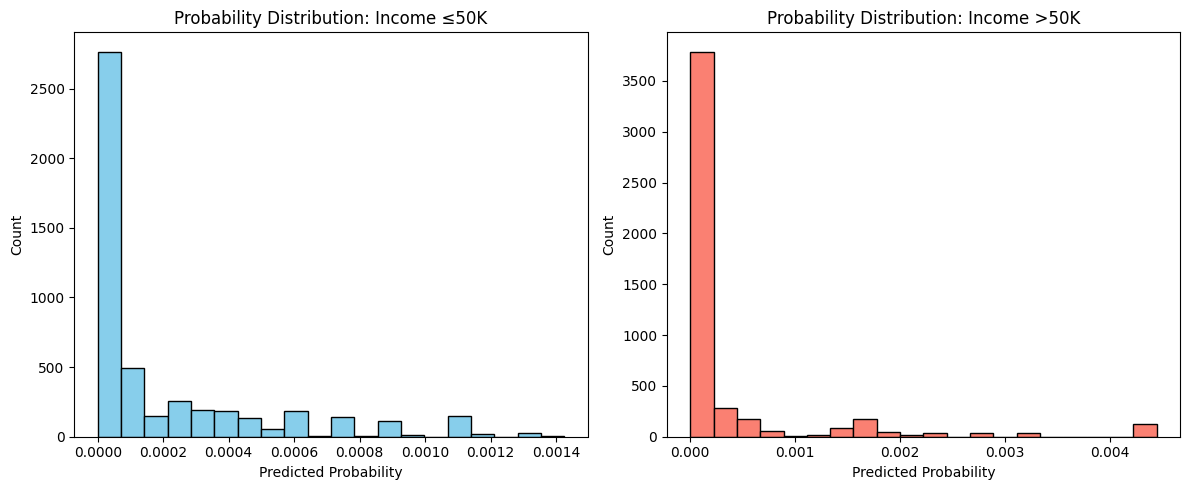

In [27]:

# get predicted log probabilities
log_proba = nb_custom.predict_log_proba(X_val)

# convert log probabilities to normal probabilities
proba = np.exp(log_proba) # 2 columns

# probability of class 0 ("<=50K") and class 1 (">50K")
p_low = proba[:, 0]
p_high = proba[:, 1]

# plotting
plt.figure(figsize=(12, 5))

# Histogram for <=50K
plt.subplot(1, 2, 1)
plt.hist(p_low, bins=20, color='skyblue', edgecolor='black')
plt.title("Probability Distribution: Income ≤50K")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")

# Histogram for >50K
plt.subplot(1, 2, 2)
plt.hist(p_high, bins=20, color='salmon', edgecolor='black')
plt.title("Probability Distribution: Income >50K")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


In [11]:
# independence assumption analysis
corr_matrix = np.corrcoef(X_train.T)
high_corr_pairs = []

print("Feature Correlations (>0.3 violates independence):")
for i in range(len(categorical_features)):
    for j in range(i+1, len(categorical_features)):
        corr = abs(corr_matrix[i, j])
        if corr > 0.3:
            high_corr_pairs.append((categorical_features[i], categorical_features[j], corr))
            print(f"  {categorical_features[i]:15} ↔ {categorical_features[j]:15}: {corr:.3f}")

print(f"\nFound {len(high_corr_pairs)} violations")
if high_corr_pairs:
    print(f"Highest: {high_corr_pairs[0][0]} ↔ {high_corr_pairs[0][1]} (r={high_corr_pairs[0][2]:.3f})")

Feature Correlations (>0.3 violates independence):
  relationship    ↔ sex            : 0.584

Found 1 violations
Highest: relationship ↔ sex (r=0.584)


Naive Bayes assumes features are conditionally independent given the class, but my correlation analysis shows this is violated. The code computes pairwise correlations between the 8 categorical features and finds relationship ↔ sex with r=0.584 (>0.3 threshold)—married men dominate >50K incomes, so these features double-count marital status signals. This is a clear independence violation, but Naive Bayes often performs well anyway since correlated features reinforce the same class prediction.


Final Test Performance:
Custom NB:  0.7879
Sklearn NB: 0.7527

Detailed Report (Custom NB):
              precision    recall  f1-score   support

       <=50K       0.90      0.81      0.85      3709
        >50K       0.54      0.72      0.62      1176

    accuracy                           0.79      4885
   macro avg       0.72      0.77      0.74      4885
weighted avg       0.82      0.79      0.80      4885



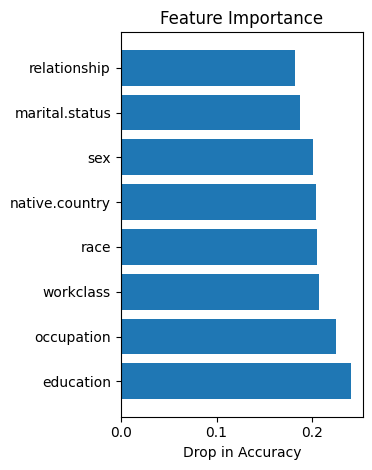

In [24]:
# performance comparison on test set
nb_custom_test = CustomNaiveBayes(alpha=1.0)
nb_custom_test.fit(X_train, y_train)
custom_test_pred = nb_custom_test.predict(X_test)

nb_sklearn_test = MultinomialNB(alpha=1.0)
nb_sklearn_test.fit(X_train, y_train)
sklearn_test_pred = nb_sklearn_test.predict(X_test)

print("\nFinal Test Performance:")
print(f"Custom NB:  {accuracy_score(y_test, custom_test_pred):.4f}")
print(f"Sklearn NB: {accuracy_score(y_test, sklearn_test_pred):.4f}")
print("\nDetailed Report (Custom NB):")
print(classification_report(y_test, custom_test_pred, target_names=le_target.classes_))

plt.subplot(1, 2, 2)
importance_idx = np.argsort(feature_importance)[::-1]
plt.barh(range(len(feature_names)), [feature_importance[i] for i in importance_idx])
plt.yticks(range(len(feature_names)), [feature_names[i] for i in importance_idx])
plt.xlabel('Drop in Accuracy')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()